In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import keras

from matplotlib import pyplot as plt
from keras import layers, models, regularizers
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

In [2]:
BATCH_SIZE = 32
IMG_SIZE = (128, 128)

In [3]:
IMAGES_DIR = "../data/images"
MASKS_DIR = "../data/masks/"
CSV_PATH = "../data/GroundTruth.csv"

In [4]:
metadata = pd.read_csv(CSV_PATH)

print(metadata.head())
print(metadata.info())

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   10015 non-null  str    
 1   MEL     10015 non-null  float64
 2   NV      10015 non-null  float64
 3   BCC     10015 non-null  float64
 4   AKIEC   10015 non-null  float64
 5   BKL     10015 non-null  float64
 6   DF      10015 non-null  float64
 7   VASC    10015 non-null  float64
dtypes: float64(7), str(1)
memory usage: 626.1 KB
None


#### CLASSES

As sete classes utilizadas são:

- **MEL:** Melanoma
- **NV:** Nevos Melanocíticos
- **BCC:** Carcinoma Basocelular
- **AKIEC:** Queratose Actínica
- **BKL:** Queratose Benigna
- **DF:** Dermatofibroma
- **VASC:** Lesão Vascular

São criados dois dicionários:

- `class_code`: nome da classe para número
- `class_name`: número para nome da classe

In [5]:
classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

class_code = {label: code for code, label in enumerate(classes)}
class_name = {code: label for code, label in enumerate(classes)}

print(class_code)
print(class_name)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}
{0: 'MEL', 1: 'NV', 2: 'BCC', 3: 'AKIEC', 4: 'BKL', 5: 'DF', 6: 'VASC'}


### CRIAÇÃO DOS RÓTULOS CODIFICADOS

A função abaixo lê os nomes das imagens disponíveis na pasta `data/images`, cruza esses nomes com o arquivo `GroundTruth.csv` e transforma a classe de cada imagem em um valor inteiro.

Esse formato é necessário porque a CNN será treinada com `SparseCategoricalCrossEntropy`.

In [6]:
def get_coded_labels(directory, metadata, class_code):
    image_names = [
        x.rsplit(".", 1)[0]
        for x in os.listdir(directory)
        if x.lower().endswith((".jpg", ",jpeg", ".png"))
    ]

    image_df = pd.DataFrame({"image": sorted(image_names)})

    merged = image_df.merge(metadata, on="image", how="inner")

    coded_labels = merged[classes].idxmax(axis=1).map(lambda x: class_code[x])

    return list(coded_labels)

### CRIAÇÃO DO DATASET

O dataset é criado redimensionando todas as imagens, associando cada imagem ao seu rótulo numérico e convertendo-as em um objeto `tf.data.Dataset`.

In [7]:
dataset = keras.utils.image_dataset_from_directory(
    directory=IMAGES_DIR,
    labels=get_coded_labels(IMAGES_DIR, metadata, class_code),
    batch_size=None,
    label_mode="int",
    shuffle=True,
    image_size=IMG_SIZE
)

Found 10015 files belonging to 7 classes.


In [8]:
train_ds, test_ds = keras.utils.split_dataset(
    dataset,
    left_size=0.8,
    shuffle=True,
    seed=42
)

### RANDOM OVER-SAMPLING E DATA AUGMENTATION

Após a divisão entre treino e teste, foi aplicado Random Over-Sampling somente ao conjunto de treino. Essa técnica replica aleatoriamente amostras das classes minoritárias até balancear a distribuição das classes no treinamento.

Em seguida, o conjunto de treino balanceado foi convertido novamente para `tf.data.Dataset`, embaralhado, organizado em batches e submetido ao Data Augmentation durante o treinamento.


In [9]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
]

def data_augmentation(images, labels):
    for layer in data_augmentation_layers:
        images = layer(images, training=True)
    
    return images, labels


In [10]:

def dataset_to_numpy(ds):
    images_list = []
    labels_list = []

    for image, label in ds:
        images_list.append(image.numpy().astype("float32"))
        labels_list.append(label.numpy())

    X = np.stack(images_list)
    y = np.array(labels_list, dtype=np.int32)

    return X, y

X_train, y_train = dataset_to_numpy(train_ds)

In [11]:
print("Distribuição original do treino:")
print(Counter(y_train))

Distribuição original do treino:
Counter({np.int32(1): 5352, np.int32(4): 903, np.int32(0): 881, np.int32(2): 407, np.int32(3): 265, np.int32(6): 114, np.int32(5): 90})


In [12]:
original_train_label_counts = pd.Series(y_train).value_counts().sort_index()
original_train_label_counts.index = [class_name[i] for i in original_train_label_counts.index]

n_samples, height, width, channels = X_train.shape

X_train_flat = X_train.reshape(n_samples, -1)

oversampler = RandomOverSampler(random_state=42)

X_train_resampled_flat, y_train_resampled = oversampler.fit_resample(
    X_train_flat,
    y_train
)

X_train_resampled = X_train_resampled_flat.reshape(-1, height, width, channels)
X_train_resampled = np.clip(X_train_resampled, 0, 255).astype("float32")
y_train_resampled = y_train_resampled.astype("int32")


In [13]:
print("\nDistribuição do treino após Random Over-Sampling:")
print(Counter(y_train_resampled))



Distribuição do treino após Random Over-Sampling:
Counter({np.int32(1): 5352, np.int32(0): 5352, np.int32(4): 5352, np.int32(2): 5352, np.int32(3): 5352, np.int32(5): 5352, np.int32(6): 5352})


In [14]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train_resampled, y_train_resampled))

train_ds = train_ds.shuffle(
    buffer_size=len(y_train_resampled),
    seed=42
)

train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.map(data_augmentation, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)


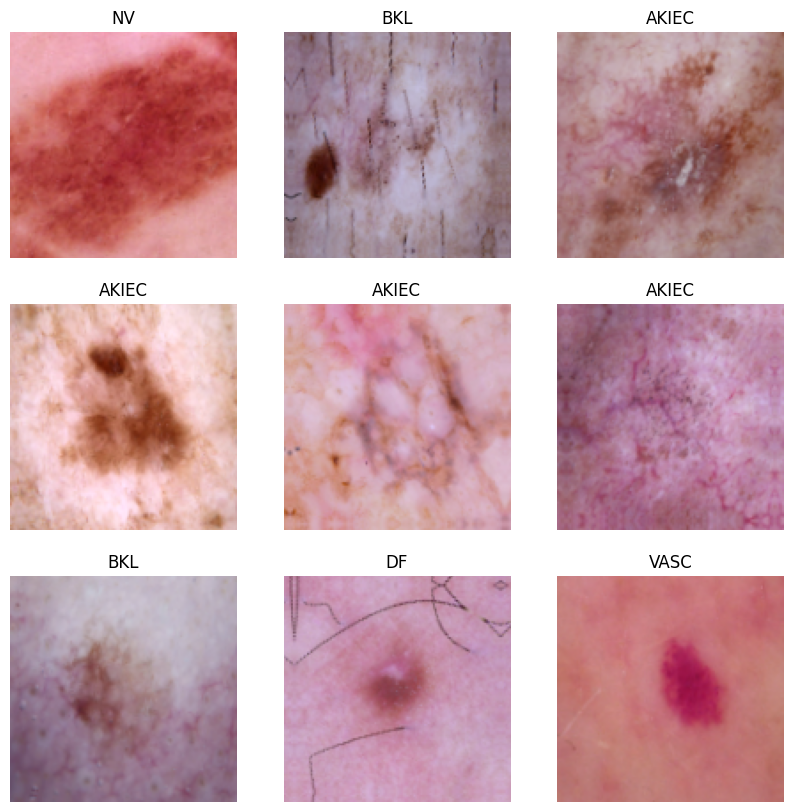

In [15]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        plt.title(class_name[int(labels[i].numpy())])
        plt.axis("off")

plt.show()

Quantidade de imagens no conjunto de treino após Random Over-Sampling: 37464


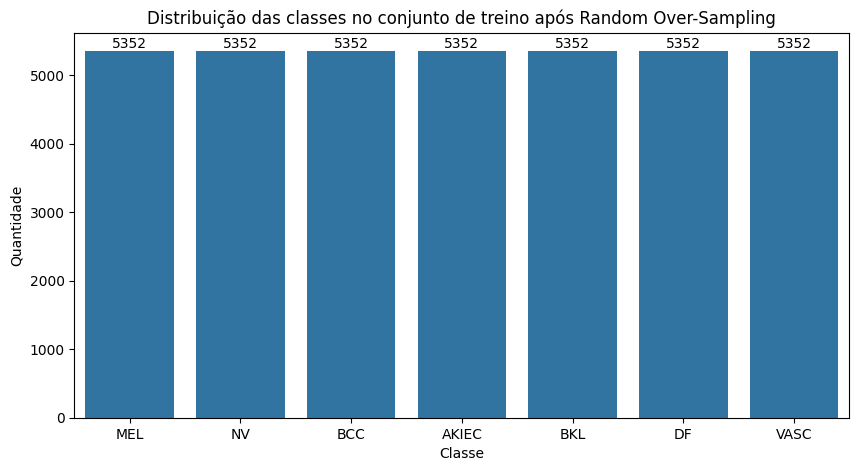

MEL      5352.0
NV       5352.0
BCC      5352.0
AKIEC    5352.0
BKL      5352.0
DF       5352.0
VASC     5352.0
dtype: object


In [16]:
train_label_df = pd.DataFrame(columns=classes)

for images, labels in train_ds.as_numpy_iterator():
    label_array = np.zeros((len(labels), len(classes)))

    for i, label in enumerate(labels):
        label_array[i, int(label)] = 1

    batch_df = pd.DataFrame(label_array, columns=classes)
    train_label_df = pd.concat([train_label_df, batch_df], ignore_index=True)

card = len(train_label_df)

print("Quantidade de imagens no conjunto de treino após Random Over-Sampling:", card)

label_counts = train_label_df.sum()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribuição das classes no conjunto de treino após Random Over-Sampling")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

print(label_counts)

In [17]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),

    layers.Dense(len(classes))
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,951 (980.28 KB)

 Trainable params: 250,247 (977.53 KB)

 Non-trainable params: 704 (2.75 KB)

In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [19]:
print("Distribuição final usada no treinamento:")
print(label_counts)

Distribuição final usada no treinamento:
MEL      5352.0
NV       5352.0
BCC      5352.0
AKIEC    5352.0
BKL      5352.0
DF       5352.0
VASC     5352.0
dtype: object


In [20]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [21]:
history = model.fit(
    train_ds,
    epochs=200,
    validation_data=test_ds,
    callbacks=[early_stopping]
)

Epoch 1/200
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 258s 219ms/step - accuracy: 0.4692 - loss: 1.5044 - val_accuracy: 0.5227 - val_loss: 1.2595
Epoch 2/200
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 304s 259ms/step - accuracy: 0.5755 - loss: 1.2403 - val_accuracy: 0.5607 - val_loss: 1.2093
Epoch 3/200
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 311s 266ms/step - accuracy: 0.6194 - loss: 1.1226 - val_accuracy: 0.5896 - val_loss: 1.1118
Epoch 4/200
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 316s 270ms/step - accuracy: 0.6524 - loss: 1.0303 - val_accuracy: 0.5477 - val_loss: 1.2372
Epoch 5/200
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 315s 269ms/step - accuracy: 0.6803 - loss: 0.9582 - val_accuracy: 0.6046 - val_loss: 1.1392
Epoch 6/200
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 314s 268ms/step - accuracy: 0.7008 - loss: 0.8925 - val_accuracy: 0.6281 - val_loss: 1.0218
Epoch 7/200
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 326s 278ms/step - accuracy: 0.7219 - loss: 0.8411 - val_accuracy: 0.6006 - val_loss: 1.0622
Epoch 8/200
1171/1171 ━━━━━━━━━━━━━━━━━━━━ 330s 282ms/s

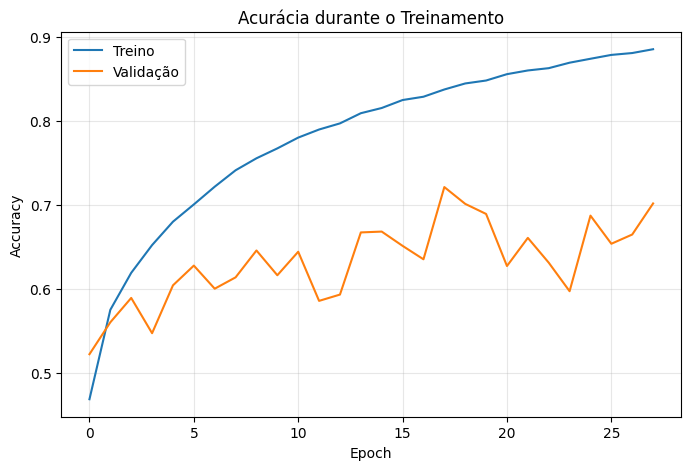

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Acurácia durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

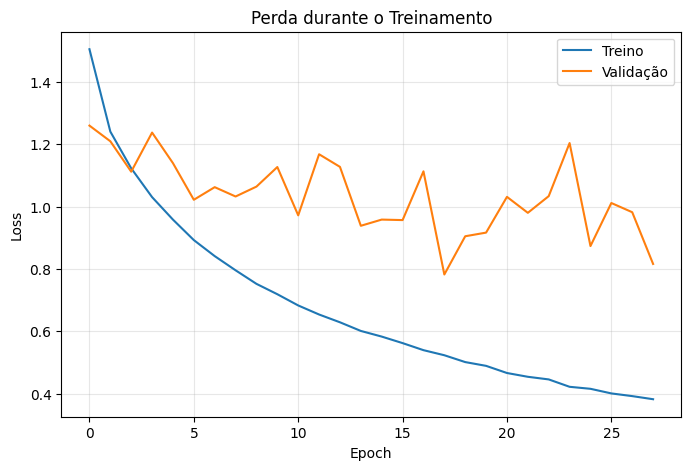

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perda durante o Treinamento")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
probability_model = tf.keras.Sequential([
    model,
    layers.Softmax()
])

In [25]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = probability_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

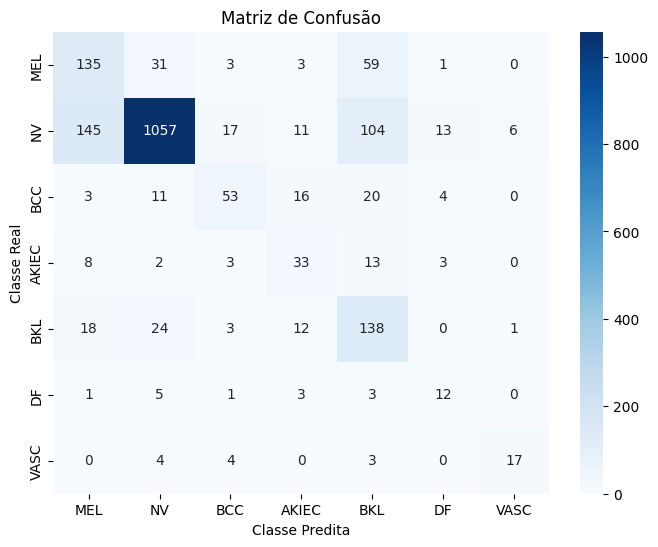

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.show()

In [27]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print("Relatório de Classificação:\n")
print(report)

Relatório de Classificação:

              precision    recall  f1-score   support

         MEL     0.4355    0.5819    0.4982       232
          NV     0.9321    0.7812    0.8500      1353
         BCC     0.6310    0.4953    0.5550       107
       AKIEC     0.4231    0.5323    0.4714        62
         BKL     0.4059    0.7041    0.5149       196
          DF     0.3636    0.4800    0.4138        25
        VASC     0.7083    0.6071    0.6538        28

    accuracy                         0.7214      2003
   macro avg     0.5571    0.5974    0.5653      2003
weighted avg     0.7810    0.7214    0.7408      2003



In [28]:
accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro')
recall_macro = recall_score(y_true, y_pred, average='macro')
f1_macro = f1_score(y_true, y_pred, average='macro')

precision_weighted = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print("MÉTRICAS GERAIS DO MODELO")
print(f"\nAccuracy: {accuracy:.4f}")
print(f"\nMacro Average:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall: {recall_macro:.4f}")
print(f"  F1-Score: {f1_macro:.4f}")
print(f"\nWeighted Average:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall: {recall_weighted:.4f}")
print(f"  F1-Score: {f1_weighted:.4f}")

MÉTRICAS GERAIS DO MODELO

Accuracy: 0.7214

Macro Average:
  Precision: 0.5571
  Recall: 0.5974
  F1-Score: 0.5653

Weighted Average:
  Precision: 0.7810
  Recall: 0.7214
  F1-Score: 0.7408


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


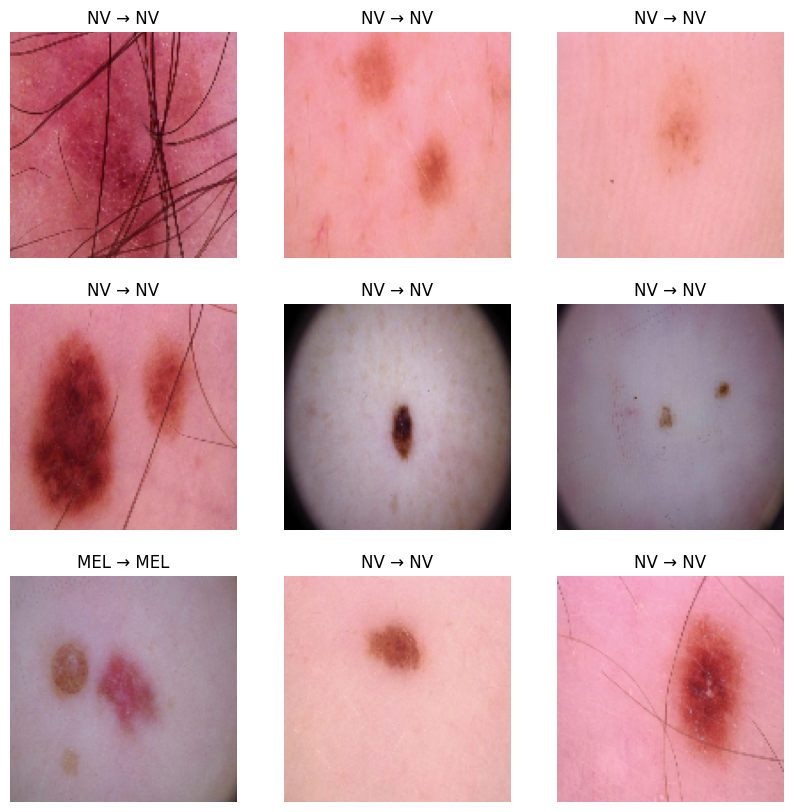

In [29]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    predictions = probability_model.predict(images)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)

        image = tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8)
        plt.imshow(image)

        true_label = class_name[int(labels[i].numpy())]
        pred_label = class_name[int(np.argmax(predictions[i]))]

        plt.title(f"{true_label} → {pred_label}")
        plt.axis("off")

plt.show()

In [30]:
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print("\nDiagnóstico final:")
print(f"Train accuracy: {final_train_acc:.4f}")
print(f"Val accuracy: {final_val_acc:.4f}")
print(f"Train loss: {final_train_loss:.4f}")
print(f"Val loss: {final_val_loss:.4f}")


Diagnóstico final:
Train accuracy: 0.8853
Val accuracy: 0.7019
Train loss: 0.3824
Val loss: 0.8161
